# agentv9_dynamic_parallel_workflow — Dynamic Parallel Branches

This version upgrades static parallel workflow to dynamic parallel workflow.

Static v9:

```text
split → all branches → synthesize
```

Dynamic v9:

```text
planner → selected branches only → synthesize
```

The key concept is `Send`.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state

`analysis_results` uses a reducer because multiple selected branches can update the same field.

```python
analysis_results: Annotated[list[str], operator.add]
```


In [3]:
import operator
from typing import Annotated, Literal, TypedDict

AnalysisName = Literal["failure_analysis", "latency_analysis", "volume_analysis"]

class AgentState(TypedDict, total=False):
    input: str
    selected_analyses: list[AnalysisName]
    analysis_results: Annotated[list[str], operator.add]
    final_answer: str


## 4. Define fallback deterministic planner

This is used if the LLM planner returns invalid JSON.


In [4]:
def fallback_select_analyses(text: str) -> list[AnalysisName]:
    normalized = text.lower()
    selected: list[AnalysisName] = []

    if any(term in normalized for term in ["failure", "failures", "failed", "error", "timeout", "reason"]):
        selected.append("failure_analysis")

    if any(term in normalized for term in ["latency", "response time", "slow", "performance"]):
        selected.append("latency_analysis")

    if any(term in normalized for term in ["volume", "traffic", "load", "count", "throughput"]):
        selected.append("volume_analysis")

    if not selected or any(term in normalized for term in ["full", "health", "overall", "summary", "release report"]):
        selected = ["failure_analysis", "latency_analysis", "volume_analysis"]

    return selected


## 5. Define LLM planner node

The planner selects one or more branches.

It returns:

```python
{"selected_analyses": [...]}
```


In [5]:
import json
from langchain_openai import ChatOpenAI

def planner_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
You are a planner for an EPP SLA analysis workflow.

Available analysis branches:
- failure_analysis: failure counts, failed_reason, errors, timeout issues
- latency_analysis: response_time, slow performance, latency trends
- volume_analysis: volume, traffic, throughput, transaction counts

Select only the branches needed for the user request.

Return only valid JSON in this exact shape:
{{"selected_analyses": ["failure_analysis", "latency_analysis"]}}

Rules:
- If the user asks for full health, overall summary, or release report, select all branches.
- If the user asks only about latency, select latency_analysis only.
- If the user asks only about failures, select failure_analysis only.
- If the user asks only about volume or traffic, select volume_analysis only.

User request:
{state["input"]}
'''

    try:
        response = llm.invoke(prompt).content.strip()
        parsed = json.loads(response)
        selected = parsed.get("selected_analyses", [])
        allowed = {"failure_analysis", "latency_analysis", "volume_analysis"}
        selected = [item for item in selected if item in allowed]
        if not selected:
            selected = fallback_select_analyses(state["input"])
    except Exception:
        selected = fallback_select_analyses(state["input"])

    return {
        "selected_analyses": selected,
        "analysis_results": [],
    }


## 6. Define dynamic fan-out with Send

`Send` dynamically chooses which nodes to run.

This is how we avoid running unnecessary branches.


In [6]:
from langgraph.constants import Send

def dynamic_fanout(state: AgentState):
    return [
        Send(analysis_name, {"input": state["input"]})
        for analysis_name in state["selected_analyses"]
    ]


/tmp/ipykernel_12879/2371969921.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


## 7. Define branch nodes


In [7]:
def failure_analysis_node(state: AgentState) -> AgentState:
    return {
        "analysis_results": [
            "Failure analysis: failure volume is concentrated in CHECK-DOMAIN, with CONNECTION_TIMEOUT as the dominant failed_reason."
        ]
    }

def latency_analysis_node(state: AgentState) -> AgentState:
    return {
        "analysis_results": [
            "Latency analysis: response_time increased during the release window, especially for CHECK-DOMAIN transactions."
        ]
    }

def volume_analysis_node(state: AgentState) -> AgentState:
    return {
        "analysis_results": [
            "Volume analysis: CHECK-DOMAIN transaction volume increased significantly compared with other commands."
        ]
    }


## 8. Define synthesis node


In [8]:
def synthesize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    selected = ", ".join(state.get("selected_analyses", []))
    results = "\n".join(f"- {item}" for item in state.get("analysis_results", []))

    prompt = f'''
User request:
{state["input"]}

Selected analyses:
{selected}

Analysis results:
{results}

Write a concise final response. Do not mention analyses that were not selected.
'''

    response = llm.invoke(prompt)
    return {"final_answer": response.content}


## 9. Build graph


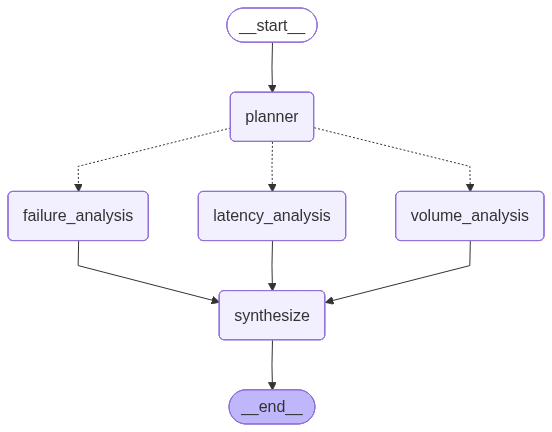

In [9]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("failure_analysis", failure_analysis_node)
    graph_builder.add_node("latency_analysis", latency_analysis_node)
    graph_builder.add_node("volume_analysis", volume_analysis_node)
    graph_builder.add_node("synthesize", synthesize_node)

    graph_builder.add_edge(START, "planner")

    graph_builder.add_conditional_edges(
        "planner",
        dynamic_fanout,
        ["failure_analysis", "latency_analysis", "volume_analysis"],
    )

    graph_builder.add_edge("failure_analysis", "synthesize")
    graph_builder.add_edge("latency_analysis", "synthesize")
    graph_builder.add_edge("volume_analysis", "synthesize")

    graph_builder.add_edge("synthesize", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 10. Visualize Mermaid graph


In [10]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	failure_analysis(failure_analysis)
	latency_analysis(latency_analysis)
	volume_analysis(volume_analysis)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	failure_analysis --> synthesize;
	latency_analysis --> synthesize;
	planner -.-> failure_analysis;
	planner -.-> latency_analysis;
	planner -.-> volume_analysis;
	volume_analysis --> synthesize;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 11. Visualize PNG graph


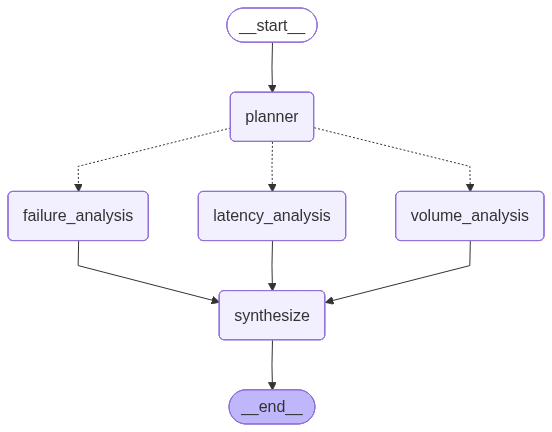

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 12. Test failure-only request


In [12]:
result = graph.invoke({"input": "Compare failures after the latest release."})
print("Selected:", result["selected_analyses"])
print("Results:", result["analysis_results"])
print("Final:", result["final_answer"])


Selected: ['failure_analysis']
Results: ['Failure analysis: failure volume is concentrated in CHECK-DOMAIN, with CONNECTION_TIMEOUT as the dominant failed_reason.']
Final: The failure analysis indicates that the majority of failures are concentrated in CHECK-DOMAIN, with CONNECTION_TIMEOUT being the predominant reason for these failures.


## 13. Test latency + volume request


In [13]:
result = graph.invoke({"input": "Check latency and traffic volume after the release."})
print("Selected:", result["selected_analyses"])
print("Results:", result["analysis_results"])
print("Final:", result["final_answer"])


Selected: ['latency_analysis', 'volume_analysis']
Results: ['Latency analysis: response_time increased during the release window, especially for CHECK-DOMAIN transactions.', 'Volume analysis: CHECK-DOMAIN transaction volume increased significantly compared with other commands.']
Final: After the release, we observed an increase in response time, particularly for CHECK-DOMAIN transactions. Additionally, the volume of CHECK-DOMAIN transactions rose significantly compared to other commands.


## 14. Test full health request


In [14]:
result = graph.invoke({"input": "Create full EPP SLA health report for latest release."})
print("Selected:", result["selected_analyses"])
print("Results:", result["analysis_results"])
print("Final:", result["final_answer"])


Selected: ['failure_analysis', 'latency_analysis', 'volume_analysis']
Results: ['Failure analysis: failure volume is concentrated in CHECK-DOMAIN, with CONNECTION_TIMEOUT as the dominant failed_reason.', 'Latency analysis: response_time increased during the release window, especially for CHECK-DOMAIN transactions.', 'Volume analysis: CHECK-DOMAIN transaction volume increased significantly compared with other commands.']
Final: **EPP SLA Health Report for Latest Release**

**Failure Analysis:**
The failure volume is predominantly concentrated in the CHECK-DOMAIN command, with CONNECTION_TIMEOUT identified as the primary reason for failures.

**Latency Analysis:**
There was a noticeable increase in response times during the release window, particularly for CHECK-DOMAIN transactions.

**Volume Analysis:**
The transaction volume for CHECK-DOMAIN saw a significant increase compared to other commands.

This report highlights critical areas of concern that require attention to improve overall

## 15. Why this matters

This pattern avoids unnecessary work.

Instead of always running:

```text
failure + latency + volume
```

the graph runs only what the planner selects.

This is valuable for:
- lower latency
- lower token usage
- fewer tool calls
- cleaner LangSmith traces
- better production control


## 16. LangSmith trace

Open project:

```text
langgraph-playground
```

Verify that branch execution matches the selected analyses.

For a failure-only request, only `failure_analysis` should run before `synthesize`.
